In [1]:
#IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.decomposition import FastICA
from sklearn.cluster import HDBSCAN

import umap
import pacmap
import hdbscan
from sklearn.metrics import silhouette_score
from matplotlib.patches import Circle

#LOADING DATA
digits = fetch_california_housing()
X = digits.data  # Feature matrix
y = digits.target  # Labels

c:\Users\sarah\anaconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
#Dimensionality Reduction
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_scaled)
X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)
X_pacmap = pacmap.PaCMAP(n_components=2, random_state=42).fit_transform(X_scaled)
X_ica = FastICA(n_components=2, random_state=42).fit_transform(X_scaled)

c:\Users\sarah\anaconda3\envs\myenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [4]:
def plot_grid_hdbscan(X_pca, X_tsne, X_umap, X_pacmap, X_ica, min_cluster_sizes):

    embeddings = [X_pca, X_tsne, X_umap, X_pacmap, X_ica]
    titles = ["PCA", "t-SNE", "UMAP", "PaCMAP", "ICA"]

    fig, axes = plt.subplots(len(min_cluster_sizes), 5, figsize=(18, 15))

    for row, mcs in enumerate(min_cluster_sizes):
        for col, (emb, title) in enumerate(zip(embeddings, titles)):

            clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs)
            labels = clusterer.fit_predict(emb)

            ax = axes[row, col]
            ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap="viridis", s=5)

            # Column titles (top row)
            if row == 0:
                ax.set_title(title)

            # Row labels
            if col == 0:
                ax.set_ylabel(f"mcs={mcs}")

            ax.set_xticks([])
            ax.set_yticks([])

    plt.suptitle("HDBSCAN Across DR Methods and min_cluster_size", fontsize=16)
    plt.tight_layout()
    plt.show()

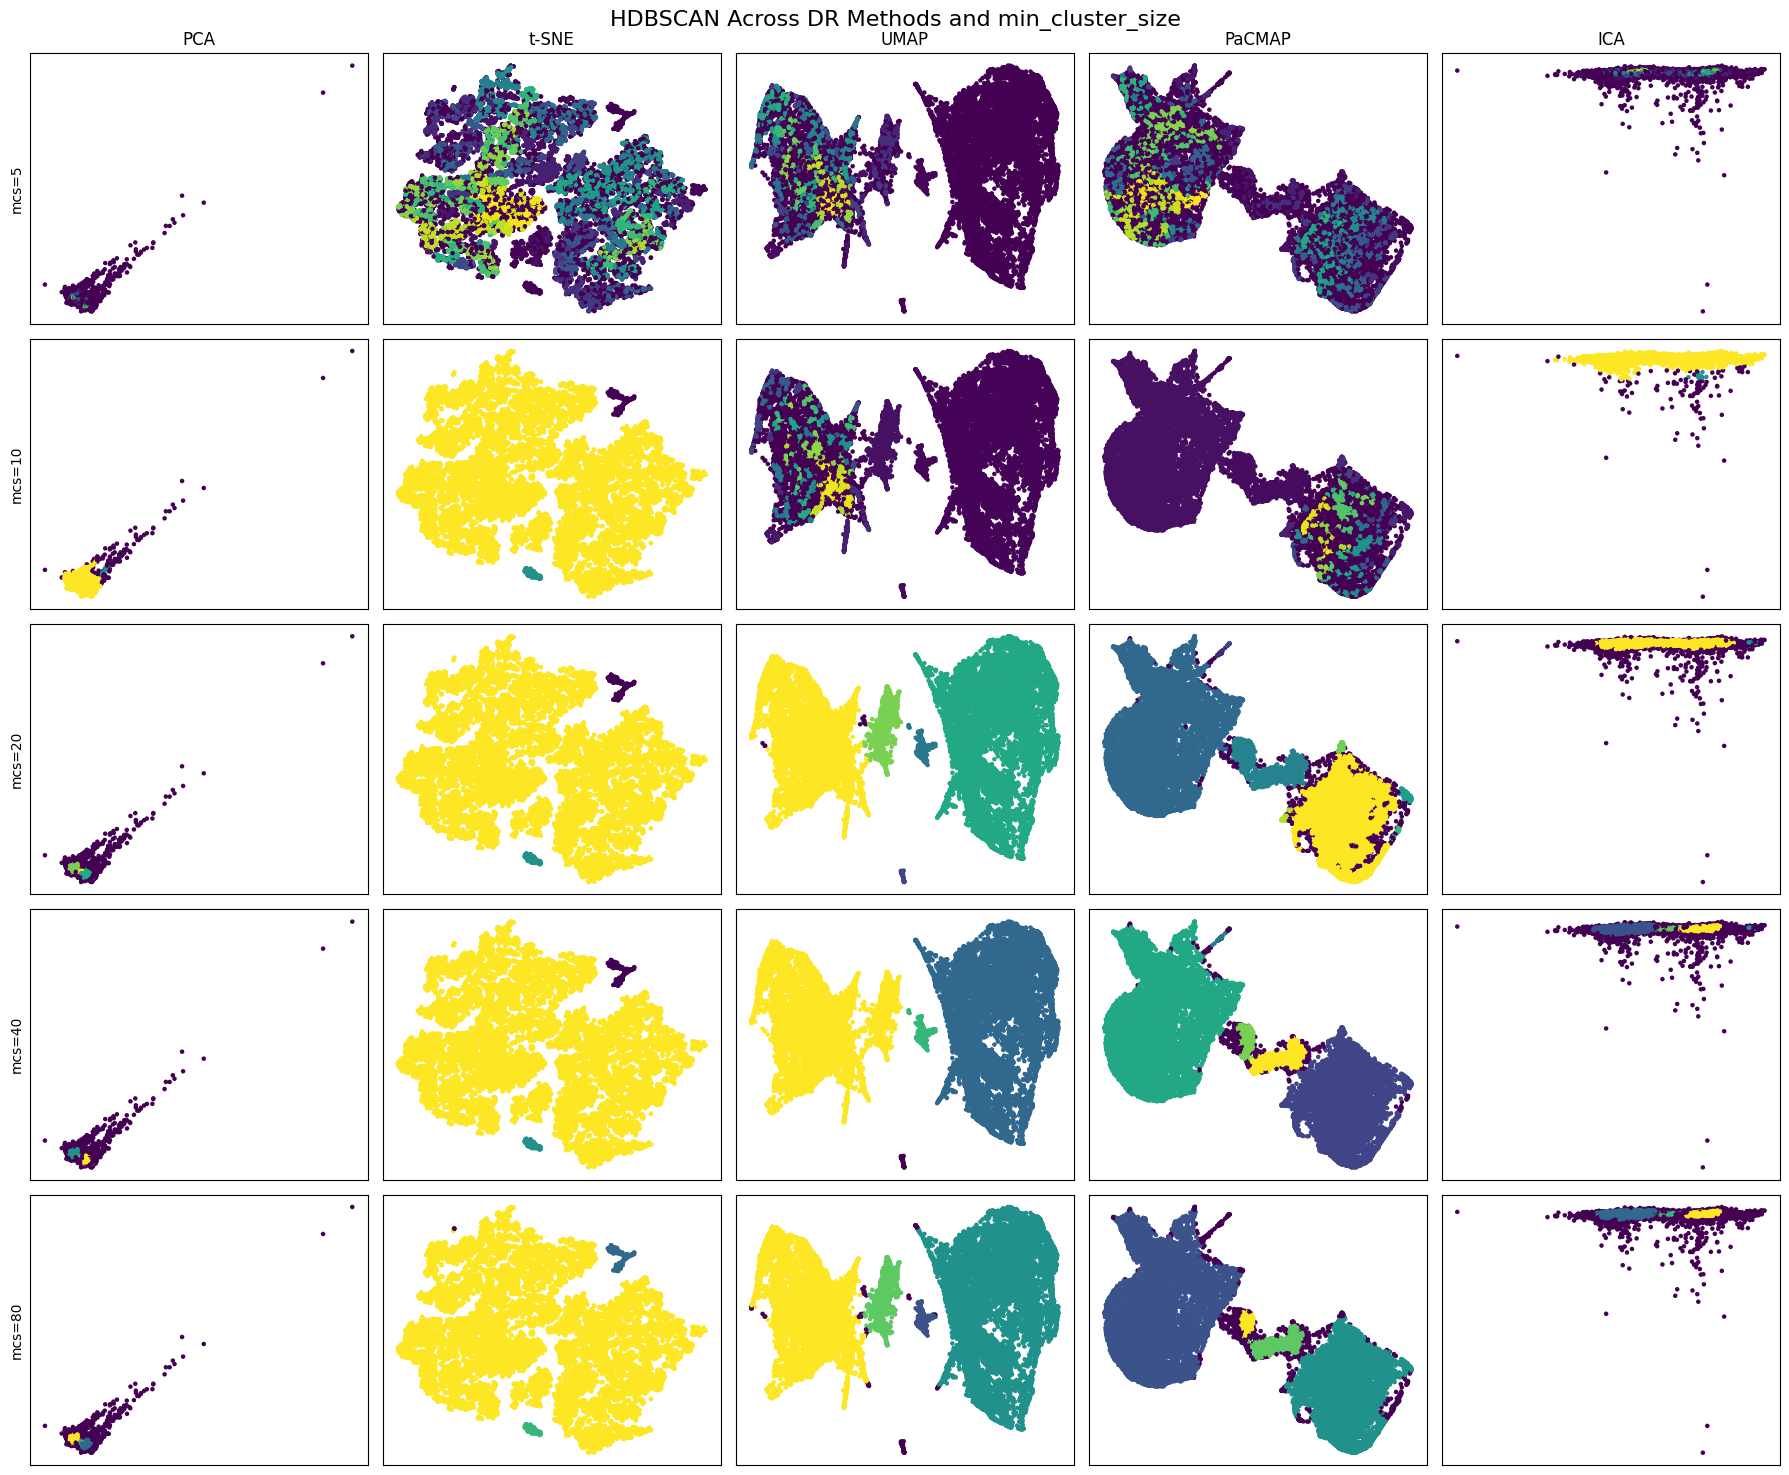

In [5]:
min_cluster_sizes = [5, 10, 20, 40, 80]

plot_grid_hdbscan(X_pca, X_tsne, X_umap, X_pacmap, X_ica, min_cluster_sizes)